In [149]:
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller


In [150]:
df = pd.read_csv("/Users/codyrlee/Documents/CodyLee_CapstoneProject/clean_data/revenue_forecast_data.csv")

df = df[df['deal_status'] == 'Closed -Won']
    
df['month'] = pd.to_datetime(df['month'])

fc_df = df.groupby('month')['actual_usd'].sum().reset_index()

In [151]:
import seaborn as sb

<Axes: xlabel='month', ylabel='actual_usd'>

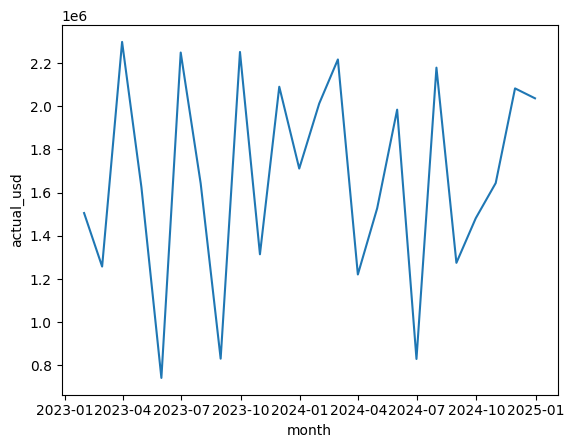

In [152]:
fc_df['month'] = pd.to_datetime(fc_df['month'])

sb.lineplot(x = 'month', y = 'actual_usd', data=fc_df)

ADF Statistic: -4.460727600196628
p-value: 0.0002313924376623684
Critical Values: {'1%': np.float64(-3.9644434814814815), '5%': np.float64(-3.0849081481481484), '10%': np.float64(-2.6818144444444445)}


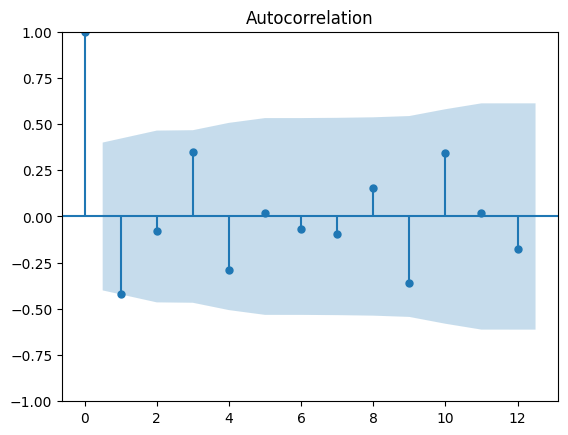

In [153]:
plot_acf(fc_df.actual_usd)

# Run ADF test      
result = adfuller(fc_df.actual_usd.dropna())

print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("Critical Values:", result[4])

# We can therefore assume the series is stationary, and therefore usable to model with ARIMA.

In [154]:
model = ARIMA(fc_df.actual_usd, order=(2,1,0))

model = model.fit()

print(model.summary())

                               SARIMAX Results                                
Dep. Variable:             actual_usd   No. Observations:                   24
Model:                 ARIMA(2, 1, 0)   Log Likelihood                -338.581
Date:                Sat, 02 Aug 2025   AIC                            683.162
Time:                        16:39:05   BIC                            686.568
Sample:                             0   HQIC                           684.018
                                 - 24                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8892      0.147     -6.067      0.000      -1.176      -0.602
ar.L2         -0.4514      0.083     -5.451      0.000      -0.614      -0.289
sigma2      1.993e+11   2.83e-13   7.04e+23      0.0

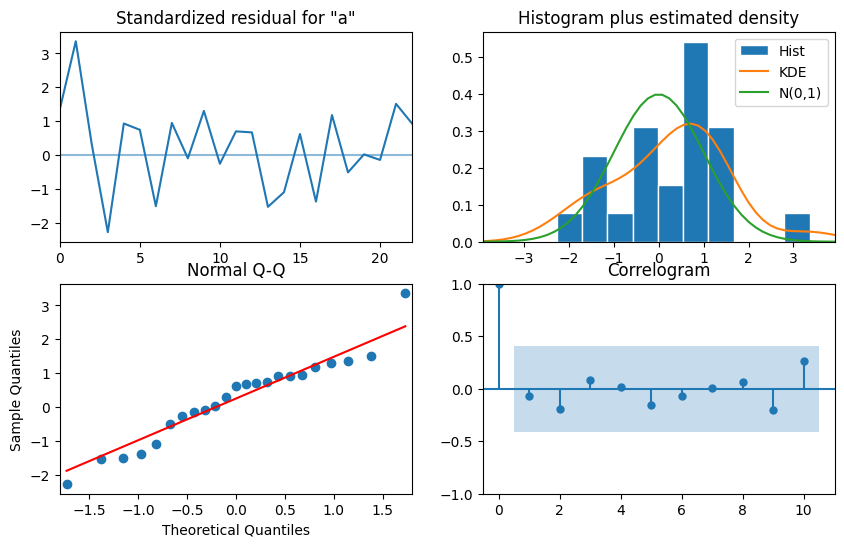

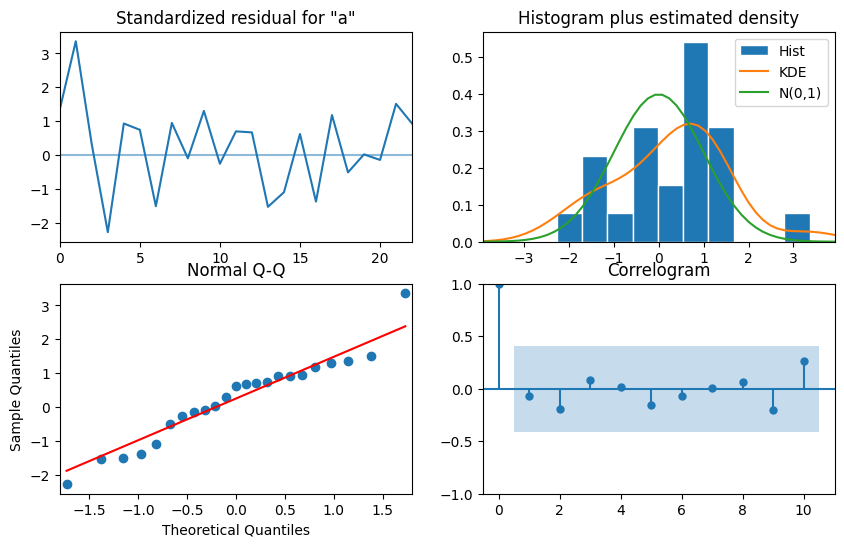

In [155]:
model.plot_diagnostics(figsize=(10, 6))

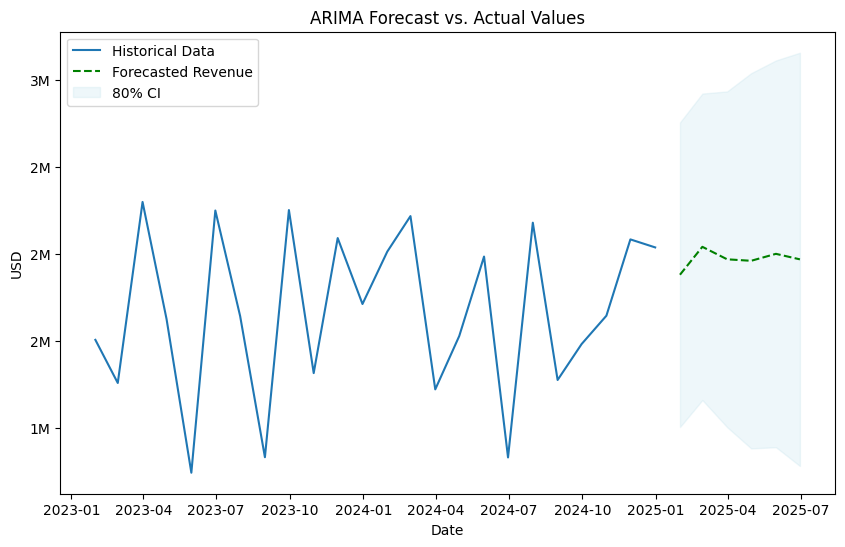

In [156]:


forecast_steps = 6
forecast = model.get_forecast(steps=forecast_steps)
conf_int = forecast.conf_int()
forecast_mean = forecast.predicted_mean
fc_df.set_index('month', inplace=True)


# Create future forecast index (monthly steps after last date)
forecast_index = pd.date_range(start=fc_df.index[-1] + pd.DateOffset(months=1),
                               periods=forecast_steps, freq='ME')

# Set the index for forecast results
forecast_mean.index = forecast_index
conf_int.index = forecast_index

def millions_formatter(x, pos):
    """Converts a number to millions with 'M' suffix."""
    return '{:.0f}M'.format(x * 1e-6)

# 5. Plot the original series and the forecast
plt.figure(figsize=(10, 6))
ax = plt.gca()

plt.plot(fc_df.index, fc_df.actual_usd, label='Historical Data')
plt.plot(forecast_mean, label='Forecasted Revenue', linestyle='--', color='green')
plt.fill_between(forecast_mean.index, 
                 conf_int.iloc[:, 0], 
                 conf_int.iloc[:, 1], 
                 color='lightblue', alpha=0.2, label='80% CI')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(millions_formatter))
plt.title('ARIMA Forecast vs. Actual Values')
plt.xlabel('Date')
plt.ylabel('USD')
plt.legend()
plt.grid(False)
plt.show()
# plt.savefig("/Users/codyrlee/Documents/CodyLee_CapstoneProject/outputs/forecast_plot.png")

In [ ]:
formatted_projection = forecast_mean.reset_index()

formatted_projection.columns = ['Month', 'Projected Revenue']

output_file_path_forecast = '/Users/codyrlee/Documents/CodyLee_CapstoneProject/outputs/forecast_table.csv'
formatted_projection.to_csv(output_file_path_forecast, index=False)
print(f"Forecast table saved to {output_file_path_forecast}")


2025-01-31    1.879473e+06
2025-02-28    2.039789e+06
2025-03-31    1.968069e+06
2025-04-30    1.959482e+06
2025-05-31    1.999491e+06
2025-06-30    1.967790e+06
Freq: ME, Name: predicted_mean, dtype: float64


       Month  Projected Revenue
0 2025-01-31       1.879473e+06
1 2025-02-28       2.039789e+06
2 2025-03-31       1.968069e+06
3 2025-04-30       1.959482e+06
4 2025-05-31       1.999491e+06
5 2025-06-30       1.967790e+06
